# MedFusionNet — Self-Contained Colab Notebook
### Swin Transformer + DenseNet-121 Hybrid | Pneumonia Detection

**This notebook is fully self-contained — no external repo needed.**
All model code, training logic, and evaluation is written directly here.

#### Fixed problems vs original:
- ✅ Class-weighted loss (74% Pneumonia / 26% Normal imbalance)
- ✅ Differential learning rates (backbone 1e-5 / head 1e-3)
- ✅ Cosine Annealing LR scheduler
- ✅ Gradient clipping (required for Swin)
- ✅ Label smoothing (prevents p=100% collapse)
- ✅ Metrics: AUC-ROC + F1 + Recall (not just accuracy)
- ✅ Early stopping on val AUC

**Workflow:** Run cells top to bottom. Only change `RUN_NAME` between experiments.

In [1]:
from google.colab import drive
from pathlib import Path
import os, sys, shutil, subprocess, zipfile

drive.mount('/content/drive')

# ── USER CONFIG ────────────────────────────────────────────────────────────────
# ⚠️  Rotate your Kaggle key after use: https://www.kaggle.com/settings
KAGGLE_JSON   = '{"username":"YOUR_USERNAME","key":"YOUR_KAGGLE_KEY"}'
DATASET_ID    = "paultimothymooney/chest-xray-pneumonia"

DRIVE_ROOT    = Path("/content/drive/MyDrive/MedFusionNet_colab")
RUNS_ROOT     = DRIVE_ROOT / "runs"
DATA_CACHE    = DRIVE_ROOT / "dataset_cache" / "chest_xray"
WORK_DIR      = Path("/content/medfusionnet")
KAGGLE_ROOT   = Path("/root/.kaggle")

for p in [DRIVE_ROOT, RUNS_ROOT, DATA_CACHE, WORK_DIR, KAGGLE_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

(KAGGLE_ROOT / "kaggle.json").write_text(KAGGLE_JSON)
os.chmod(KAGGLE_ROOT / "kaggle.json", 0o600)

print("✅ Drive mounted")
print("   DRIVE_ROOT :", DRIVE_ROOT)
print("   RUNS_ROOT  :", RUNS_ROOT)
print("   DATA_CACHE :", DATA_CACHE)

Mounted at /content/drive
✅ Drive mounted
   DRIVE_ROOT : /content/drive/MyDrive/MedFusionNet_colab
   RUNS_ROOT  : /content/drive/MyDrive/MedFusionNet_colab/runs
   DATA_CACHE : /content/drive/MyDrive/MedFusionNet_colab/dataset_cache/chest_xray


In [2]:
import subprocess, sys

pkgs = ["kaggle", "timm", "scikit-learn", "matplotlib", "pandas", "Pillow"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs, check=True)

import torch
print("✅ Dependencies installed")
print("   PyTorch :", torch.__version__)
print("   CUDA    :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("   GPU     :", torch.cuda.get_device_name(0))
else:
    print("   ⚠️  No GPU detected — go to Runtime → Change runtime type → T4 GPU")

✅ Dependencies installed
   PyTorch : 2.10.0+cu128
   CUDA    : True
   GPU     : Tesla T4


In [3]:
import zipfile, shutil, subprocess

def dataset_ready(root):
    return (root / "train").exists() and (root / "test").exists()

if not dataset_ready(DATA_CACHE):
    print("📥 Dataset not on Drive yet. Downloading from Kaggle (~1.2 GB)...")
    tmp = WORK_DIR / "kaggle_dl"
    tmp.mkdir(exist_ok=True)
    subprocess.run(["kaggle", "datasets", "download", "-d", DATASET_ID,
                    "-p", str(tmp), "--force"], check=True)
    for z in tmp.glob("*.zip"):
        print("Extracting:", z.name)
        with zipfile.ZipFile(z) as f:
            f.extractall(tmp)
    found = None
    for p in [tmp] + sorted(tmp.rglob("*")):
        if p.is_dir() and (p/"train").exists() and (p/"test").exists():
            found = p; break
    if not found:
        raise RuntimeError("Could not find dataset folder after extraction.")
    if DATA_CACHE.exists(): shutil.rmtree(DATA_CACHE)
    shutil.copytree(found, DATA_CACHE)
    print("✅ Dataset cached to Drive — will never download again")
else:
    print("✅ Dataset already on Drive — skipping download")

# ── Copy to fast local runtime storage ────────────────────────────────────────
DATA_DIR = WORK_DIR / "data"
if not dataset_ready(DATA_DIR):
    print("Copying from Drive to runtime (fast local storage)...")
    if DATA_DIR.exists(): shutil.rmtree(DATA_DIR)
    shutil.copytree(DATA_CACHE, DATA_DIR)
    print("✅ Done copying")
else:
    print("✅ Data already in runtime — skipping copy")

# ── Show class distribution ────────────────────────────────────────────────────
print("\n📊 Dataset class distribution:")
for split in ["train", "val", "test"]:
    split_dir = DATA_DIR / split
    if not split_dir.exists(): continue
    counts = {d.name: len(list(d.glob("*"))) for d in sorted(split_dir.iterdir()) if d.is_dir()}
    total = sum(counts.values())
    print(f"\n  {split.upper()} ({total} images):")
    for cls, n in counts.items():
        pct = 100*n/total
        bar = "█" * int(pct/3)
        print(f"    {cls:<12} {n:>5}  ({pct:.1f}%)  {bar}")

print("\n✅ Dataset ready at:", DATA_DIR)

✅ Dataset already on Drive — skipping download
Copying from Drive to runtime (fast local storage)...
✅ Done copying

📊 Dataset class distribution:

  TRAIN (5216 images):
    NORMAL        1341  (25.7%)  ████████
    PNEUMONIA     3875  (74.3%)  ████████████████████████

  VAL (16 images):
    NORMAL           8  (50.0%)  ████████████████
    PNEUMONIA        8  (50.0%)  ████████████████

  TEST (624 images):
    NORMAL         234  (37.5%)  ████████████
    PNEUMONIA      390  (62.5%)  ████████████████████

✅ Dataset ready at: /content/medfusionnet/data


## Model: Swin Transformer + DenseNet-121 Hybrid

In [4]:
import torch
import torch.nn as nn
import timm

class MedFusionNet(nn.Module):
    """
    Hybrid architecture:
      - Swin-Tiny Transformer  → global context (patches + attention)
      - DenseNet-121           → local texture features (CNNs)
      - Fusion head            → concat → BN → Dropout → Linear
    """
    def __init__(self, num_classes=2, pretrained=True, dropout=0.4):
        super().__init__()

        # ── Swin Transformer backbone ──────────────────────────────────────────
        self.swin = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=pretrained,
            num_classes=0,      # remove classifier head
        )
        swin_dim = self.swin.num_features  # 768

        # ── DenseNet-121 backbone ──────────────────────────────────────────────
        self.densenet = timm.create_model(
            "densenet121",
            pretrained=pretrained,
            num_classes=0,      # remove classifier head
            global_pool="avg",
        )
        dense_dim = self.densenet.num_features  # 1024

        # ── Fusion head ────────────────────────────────────────────────────────
        fused_dim = swin_dim + dense_dim  # 1792
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        f_swin  = self.swin(x)      # (B, 768)
        f_dense = self.densenet(x)  # (B, 1024)
        fused   = torch.cat([f_swin, f_dense], dim=1)  # (B, 1792)
        return self.fusion(fused)

    def get_param_groups(self, lr_backbone, lr_head):
        """Return param groups for differential learning rates."""
        backbone_params = list(self.swin.parameters()) + list(self.densenet.parameters())
        head_params     = list(self.fusion.parameters())
        return [
            {"params": backbone_params, "lr": lr_backbone},
            {"params": head_params,     "lr": lr_head},
        ]

# Quick sanity check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_m = MedFusionNet(pretrained=False).to(device)
_x = torch.randn(2, 3, 224, 224).to(device)
_out = _m(_x)
assert _out.shape == (2, 2), f"Unexpected output shape: {_out.shape}"
del _m, _x, _out
print("✅ MedFusionNet architecture OK")
print(f"   Running on: {device}")

✅ MedFusionNet architecture OK
   Running on: cuda


## Data Pipeline

In [5]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np

def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225]),
        ])

def build_loaders(data_dir, batch_size=16, num_workers=2, val_split=0.1):
    train_raw  = datasets.ImageFolder(data_dir / "train", get_transforms(True))
    test_ds    = datasets.ImageFolder(data_dir / "test",  get_transforms(False))

    # Use provided val folder if it exists and has images, else carve from train
    val_dir = data_dir / "val"
    val_has_data = val_dir.exists() and sum(1 for _ in val_dir.rglob("*.*")) > 10
    if val_has_data:
        val_ds   = datasets.ImageFolder(val_dir, get_transforms(False))
        train_ds = train_raw
    else:
        n_val    = int(len(train_raw) * val_split)
        n_train  = len(train_raw) - n_val
        train_ds, val_ds = random_split(train_raw, [n_train, n_val],
                                        generator=torch.Generator().manual_seed(42))

    # ── Compute class weights from training set ────────────────────────────────
    if hasattr(train_ds, 'dataset'):   # it's a Subset
        all_targets = [train_ds.dataset.targets[i] for i in train_ds.indices]
    else:
        all_targets = train_ds.targets

    classes    = sorted(set(all_targets))
    counts     = np.array([all_targets.count(c) for c in classes], dtype=float)
    weights    = counts.sum() / (len(classes) * counts)
    class_weights = torch.tensor(weights, dtype=torch.float)

    print("⚖️  Class weights:")
    class_names = train_raw.classes
    for cls_name, w in zip(class_names, class_weights):
        print(f"    {cls_name:<12} weight = {w:.4f}")

    loaders = {
        "train": DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                            num_workers=num_workers, pin_memory=True),
        "val":   DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True),
        "test":  DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True),
    }
    return loaders, class_weights, class_names

print("✅ Data pipeline defined")

✅ Data pipeline defined


## Training Configuration

| Parameter | Value | Reason |
|-----------|-------|--------|
| `EPOCHS` | 40 | Enough to converge; early stopping cuts it short if needed |
| `BATCH_SIZE` | 16 | Fits T4 GPU; use 8 if OOM |
| `LR_BACKBONE` | 1e-5 | Pretrained Swin+DenseNet: fine-tune very slowly |
| `LR_HEAD` | 1e-3 | Fusion head: learn fast from scratch |
| `LABEL_SMOOTHING` | 0.1 | Prevents overconfident outputs / p=100% collapse |
| `GRAD_CLIP` | 1.0 | Required for Swin Transformer stability |
| `EARLY_STOP_PATIENCE` | 8 | Stop if val AUC doesn't improve for 8 epochs |

> **Only change `RUN_NAME` between experiments.**

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  TRAINING CONFIGURATION — change RUN_NAME only
# ══════════════════════════════════════════════════════════════════════════════

RUN_NAME             = "run_v1"     # ← change this for each new experiment

EPOCHS               = 40
BATCH_SIZE           = 16           # use 8 if you get out-of-memory errors
NUM_WORKERS          = 2
VAL_SPLIT            = 0.10         # used only if no val/ folder in dataset

LR_BACKBONE          = 1e-5         # pretrained backbone — fine-tune gently
LR_HEAD              = 1e-3         # fusion head — learn aggressively
LABEL_SMOOTHING      = 0.1
GRAD_CLIP            = 1.0
USE_AMP              = True         # mixed precision — faster on T4
EARLY_STOP_PATIENCE  = 8
USE_PRETRAINED       = True

# ── Scheduler ─────────────────────────────────────────────────────────────────
SCHEDULER_T0         = 10           # cosine restart every 10 epochs
SCHEDULER_T_MULT     = 2            # then 20, 40, ...

# ── Run directory ─────────────────────────────────────────────────────────────
RUN_DIR = RUNS_ROOT / RUN_NAME
(RUN_DIR / "checkpoints").mkdir(parents=True, exist_ok=True)
(RUN_DIR / "logs").mkdir(exist_ok=True)

print(f"✅ Config set for run: '{RUN_NAME}'")
print(f"   RUN_DIR    : {RUN_DIR}")
print(f"   LR backbone: {LR_BACKBONE}  |  LR head: {LR_HEAD}")
print(f"   Batch size : {BATCH_SIZE}  |  Epochs: {EPOCHS}")
print(f"   Label smooth: {LABEL_SMOOTHING}  |  Grad clip: {GRAD_CLIP}")

✅ Config set for run: 'run_v1'
   RUN_DIR    : /content/drive/MyDrive/MedFusionNet_colab/runs/run_v1
   LR backbone: 1e-05  |  LR head: 0.001
   Batch size : 16  |  Epochs: 40
   Label smooth: 0.1  |  Grad clip: 1.0


## Training

In [ ]:
import time, json, csv
import torch
import torch.nn as nn
from torch.amp import GradScaler, autocast
from sklearn.metrics import roc_auc_score, f1_score, recall_score, confusion_matrix
import numpy as np

# ── Build data loaders ─────────────────────────────────────────────────────────
loaders, class_weights, class_names = build_loaders(
    DATA_DIR, BATCH_SIZE, NUM_WORKERS, VAL_SPLIT)

print(f"   Train batches: {len(loaders['train'])}  |  "
      f"Val batches: {len(loaders['val'])}  |  "
      f"Test batches: {len(loaders['test'])}")

# ── Model ──────────────────────────────────────────────────────────────────────
model = MedFusionNet(num_classes=2, pretrained=USE_PRETRAINED).to(device)

# ── Optimizer with differential LRs ───────────────────────────────────────────
optimizer = torch.optim.AdamW(
    model.get_param_groups(LR_BACKBONE, LR_HEAD),
    weight_decay=1e-4
)

# ── Scheduler ─────────────────────────────────────────────────────────────────
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=SCHEDULER_T0, T_mult=SCHEDULER_T_MULT)

# ── Loss: weighted + label smoothing ──────────────────────────────────────────
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    label_smoothing=LABEL_SMOOTHING
)

scaler = GradScaler('cuda', enabled=USE_AMP)

# ── Metrics helper ────────────────────────────────────────────────────────────
def evaluate(loader):
    model.eval()
    all_logits, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with autocast('cuda', enabled=USE_AMP):
                logits = model(imgs)
                loss   = criterion(logits, labels)
            total_loss += loss.item()
            all_logits.append(logits.cpu())
            all_labels.append(labels.cpu())
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels).numpy()
    probs  = torch.softmax(logits, dim=1)[:, 1].numpy()
    preds  = logits.argmax(dim=1).numpy()
    auc    = roc_auc_score(labels, probs) if len(set(labels)) > 1 else 0.5
    f1     = f1_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    acc    = (preds == labels).mean()
    return {
        "loss":   total_loss / len(loader),
        "auc":    auc,
        "f1":     f1,
        "recall": recall,
        "acc":    acc,
    }

# ── CSV log ───────────────────────────────────────────────────────────────────
log_path = RUN_DIR / "logs" / "metrics.csv"
log_fields = ["epoch","train_loss","val_loss","val_auc","val_f1","val_recall","val_acc","lr"]
with open(log_path, "w", newline="") as f:
    csv.DictWriter(f, fieldnames=log_fields).writeheader()

# ── Training loop ─────────────────────────────────────────────────────────────
best_auc          = 0.0
patience_counter  = 0
history           = []

print(f"\n🚀 Starting training for {EPOCHS} epochs...")
print(f"   Early stop patience: {EARLY_STOP_PATIENCE} epochs (metric: val_auc)")
print("-" * 75)

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    t0 = time.time()

    for imgs, labels in loaders["train"]:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast('cuda', enabled=USE_AMP):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    scheduler.step()

    train_loss /= len(loaders["train"])
    val_m       = evaluate(loaders["val"])
    elapsed     = time.time() - t0
    lr_now      = optimizer.param_groups[1]["lr"]  # head LR

    row = {
        "epoch":      epoch,
        "train_loss": round(train_loss, 4),
        "val_loss":   round(val_m["loss"],   4),
        "val_auc":    round(val_m["auc"],    4),
        "val_f1":     round(val_m["f1"],     4),
        "val_recall": round(val_m["recall"], 4),
        "val_acc":    round(val_m["acc"],    4),
        "lr":         f"{lr_now:.2e}",
    }
    history.append(row)

    # Save CSV row
    with open(log_path, "a", newline="") as f:
        csv.DictWriter(f, fieldnames=log_fields).writerow(row)

    # Checkpoint
    ckpt_last = RUN_DIR / "checkpoints" / "last.pth"
    torch.save({"epoch": epoch, "model": model.state_dict(),
                "optimizer": optimizer.state_dict(), "auc": val_m["auc"]}, ckpt_last)

    tag = ""
    if val_m["auc"] > best_auc:
        best_auc = val_m["auc"]
        patience_counter = 0
        ckpt_best = RUN_DIR / "checkpoints" / "best.pth"
        torch.save({"epoch": epoch, "model": model.state_dict(),
                    "auc": best_auc}, ckpt_best)
        tag = "  ← best"
    else:
        patience_counter += 1

    print(f"Ep {epoch:03d}/{EPOCHS}  "
          f"loss {train_loss:.4f}→{val_m['loss']:.4f}  "
          f"AUC {val_m['auc']:.4f}  "
          f"F1 {val_m['f1']:.4f}  "
          f"Recall {val_m['recall']:.4f}  "
          f"[{elapsed:.0f}s]{tag}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⏹  Early stop at epoch {epoch} (no AUC improvement for {EARLY_STOP_PATIENCE} epochs)")
        break

print(f"\n✅ Training complete. Best val AUC: {best_auc:.4f}")
print(f"   Best checkpoint: {RUN_DIR / 'checkpoints' / 'best.pth'}")

## Training Curves

,epoch,train_loss,val_loss,val_auc,val_f1,val_recall,val_acc,lr
0,1,0.3870,0.4724,0.9375,0.8235,0.875,0.8125,0.000976
1,2,0.3506,0.3548,1.0000,0.8889,1.000,0.8750,0.000905
2,3,0.3329,0.8278,0.9688,0.7273,1.000,0.6250,0.000794
3,4,0.3356,0.7354,1.0000,0.8000,1.000,0.7500,0.000655
4,5,0.3106,0.4743,1.0000,0.8889,1.000,0.8750,0.000500
5,6,0.3096,0.3118,1.0000,0.8889,1.000,0.8750,0.000345
6,7,0.3059,0.2395,1.0000,1.0000,1.000,1.0000,0.000206
7,8,0.3071,0.3998,1.0000,0.8889,1.000,0.8750,0.000096
8,9,0.3008,0.1940,1.0000,1.0000,1.000,1.0000,0.000024
9,10,0.3053,0.2518,1.0000,0.9412,1.000,0.9375,0.001000


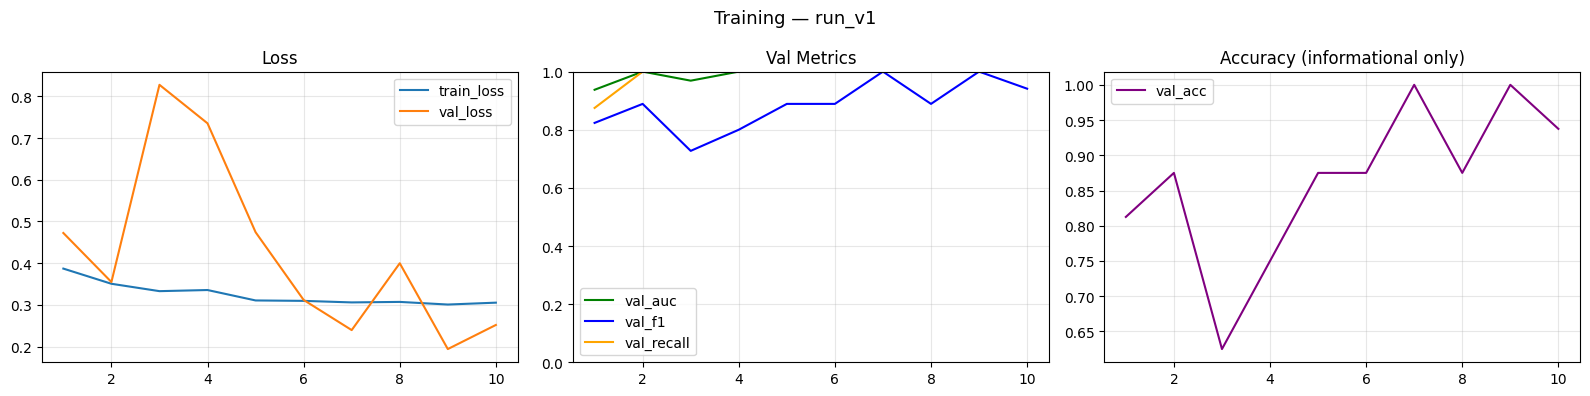


📊 Best epoch summary:
   epoch        2.0
   train_loss   0.3506
   val_loss     0.3548
   val_auc      1.0
   val_f1       0.8889
   val_recall   1.0
   val_acc      0.875
   lr           0.000905


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

df = pd.read_csv(RUN_DIR / "logs" / "metrics.csv")
display(df.tail(10))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Training — {RUN_NAME}", fontsize=13)

axes[0].plot(df.epoch, df.train_loss, label="train_loss")
axes[0].plot(df.epoch, df.val_loss,   label="val_loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(df.epoch, df.val_auc,    label="val_auc",    color="green")
axes[1].plot(df.epoch, df.val_f1,     label="val_f1",     color="blue")
axes[1].plot(df.epoch, df.val_recall, label="val_recall", color="orange")
axes[1].set_title("Val Metrics"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

axes[2].plot(df.epoch, df.val_acc, label="val_acc", color="purple")
axes[2].set_title("Accuracy (informational only)"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\n📊 Best epoch summary:")
best_row = df.loc[df.val_auc.idxmax()]
for k, v in best_row.items():
    print(f"   {k:<12} {v}")

## ⚡ Evaluate Only (use this after reconnecting)

**If your session restarted and training is already done**, run cells 1→2→3→5→7→9
then run the cell below instead of re-training. It loads your saved checkpoint from Drive.

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
#  EVALUATE ONLY — run this if you reconnected and training is already done
#  Skips retraining entirely, loads best.pth from Drive
# ══════════════════════════════════════════════════════════════════════════════
import torch

# Rebuild data loaders (needed for test set)
loaders, class_weights, class_names = build_loaders(
    DATA_DIR, BATCH_SIZE, NUM_WORKERS, VAL_SPLIT)
print(f"✅ Loaders ready — test batches: {len(loaders['test'])}")

# Rebuild model and load checkpoint
model = MedFusionNet(num_classes=2, pretrained=False).to(device)

ckpt_path = RUN_DIR / "checkpoints" / "best.pth"
assert ckpt_path.exists(), (
    f"Checkpoint not found: {ckpt_path}\n"
    f"Make sure RUN_NAME = '{RUN_NAME}' matches the run you trained."
)

ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model"])
print(f"✅ Loaded best checkpoint — epoch {ckpt['epoch']}, AUC {ckpt['auc']:.4f}")
print("\n👉 Now run the 'Final Evaluation on Test Set' cell below")

⚖️  Class weights:
    NORMAL       weight = 1.9448
    PNEUMONIA    weight = 0.6730
✅ Loaders ready — test batches: 39
✅ Loaded best checkpoint — epoch 2, AUC 1.0000

👉 Now run the 'Final Evaluation on Test Set' cell below


## Final Evaluation on Test Set

✅ Loaded best checkpoint (epoch 2, AUC 1.0000)

📋 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.86      0.90       234
   PNEUMONIA       0.92      0.97      0.94       390

    accuracy                           0.93       624
   macro avg       0.93      0.91      0.92       624
weighted avg       0.93      0.93      0.93       624

   AUC-ROC: 0.9756


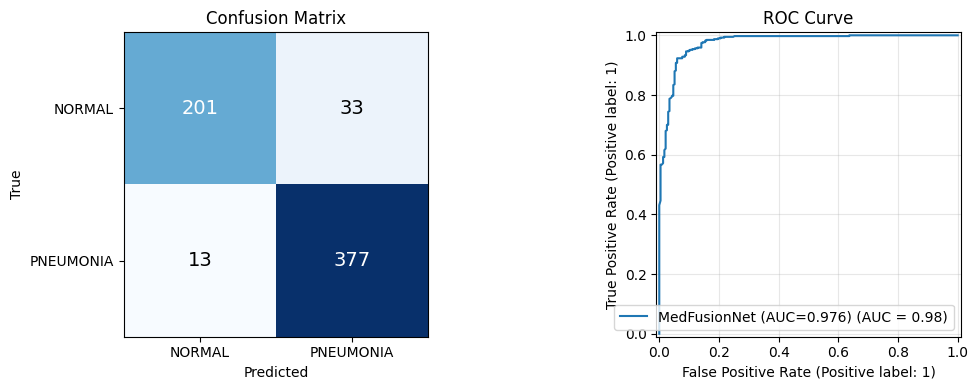


✅ Predictions saved to Drive: /content/drive/MyDrive/MedFusionNet_colab/runs/run_v1/outputs/test_predictions.csv


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,true_label,true_class,pred_label,pred_class,prob_pneumonia
0,0,NORMAL,0,NORMAL,0.036987
1,0,NORMAL,0,NORMAL,0.006836
2,0,NORMAL,0,NORMAL,0.010345
3,0,NORMAL,0,NORMAL,0.005184
4,0,NORMAL,0,NORMAL,0.009460
5,0,NORMAL,0,NORMAL,0.004490
6,0,NORMAL,0,NORMAL,0.011139
7,0,NORMAL,0,NORMAL,0.025940
8,0,NORMAL,0,NORMAL,0.282471
9,0,NORMAL,0,NORMAL,0.014603


In [9]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, RocCurveDisplay)
from IPython.display import display

# Load best checkpoint
ckpt_path = RUN_DIR / "checkpoints" / "best.pth"
assert ckpt_path.exists(), f"best.pth not found: {ckpt_path}"
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model"])
print(f"✅ Loaded best checkpoint (epoch {ckpt['epoch']}, AUC {ckpt['auc']:.4f})")

# Run on test set
model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for imgs, labels in loaders["test"]:
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(imgs)
        all_logits.append(logits.cpu())
        all_labels.append(labels)

logits = torch.cat(all_logits)
labels = torch.cat(all_labels).numpy()
probs  = torch.softmax(logits, dim=1)[:, 1].numpy()
preds  = logits.argmax(dim=1).numpy()

# ── Report ─────────────────────────────────────────────────────────────────────
print("\n📋 Classification Report:")
print(classification_report(labels, preds, target_names=class_names))

auc = roc_auc_score(labels, probs)
print(f"   AUC-ROC: {auc:.4f}")

# ── Confusion matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(labels, preds)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(class_names); axes[0].set_yticklabels(class_names)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha="center", va="center",
                     color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=14)

RocCurveDisplay.from_predictions(labels, probs, ax=axes[1], name=f"MedFusionNet (AUC={auc:.3f})")
axes[1].set_title("ROC Curve"); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ── Save predictions CSV ────────────────────────────────────────────────────────
out_dir = RUN_DIR / "outputs"
out_dir.mkdir(exist_ok=True)
pred_df = pd.DataFrame({
    "true_label":  labels,
    "true_class":  [class_names[l] for l in labels],
    "pred_label":  preds,
    "pred_class":  [class_names[p] for p in preds],
    "prob_pneumonia": probs,
})
csv_out = out_dir / "test_predictions.csv"
pred_df.to_csv(csv_out, index=False)
print(f"\n✅ Predictions saved to Drive: {csv_out}")
display(pred_df.head(10))

## 🔍 GradCAM — Visual Explainability

GradCAM highlights **which regions of the X-ray** the model used to make its decision.
This is critical for medical AI — it lets you verify the model is looking at the lungs,
not at irrelevant artifacts like text or borders.

- 🔴 **Red/Yellow areas** = regions the model focused on most
- 🔵 **Blue areas** = regions largely ignored
- A good model should highlight the **lung fields**, especially lower lobes for pneumonia

✅ GradCAM ready


/tmp/ipykernel_3784/3156639294.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3784/3156639294.py:157: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches="tight")


✅ GradCAM saved to: /content/drive/MyDrive/MedFusionNet_colab/runs/run_v1/outputs/gradcam_results.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


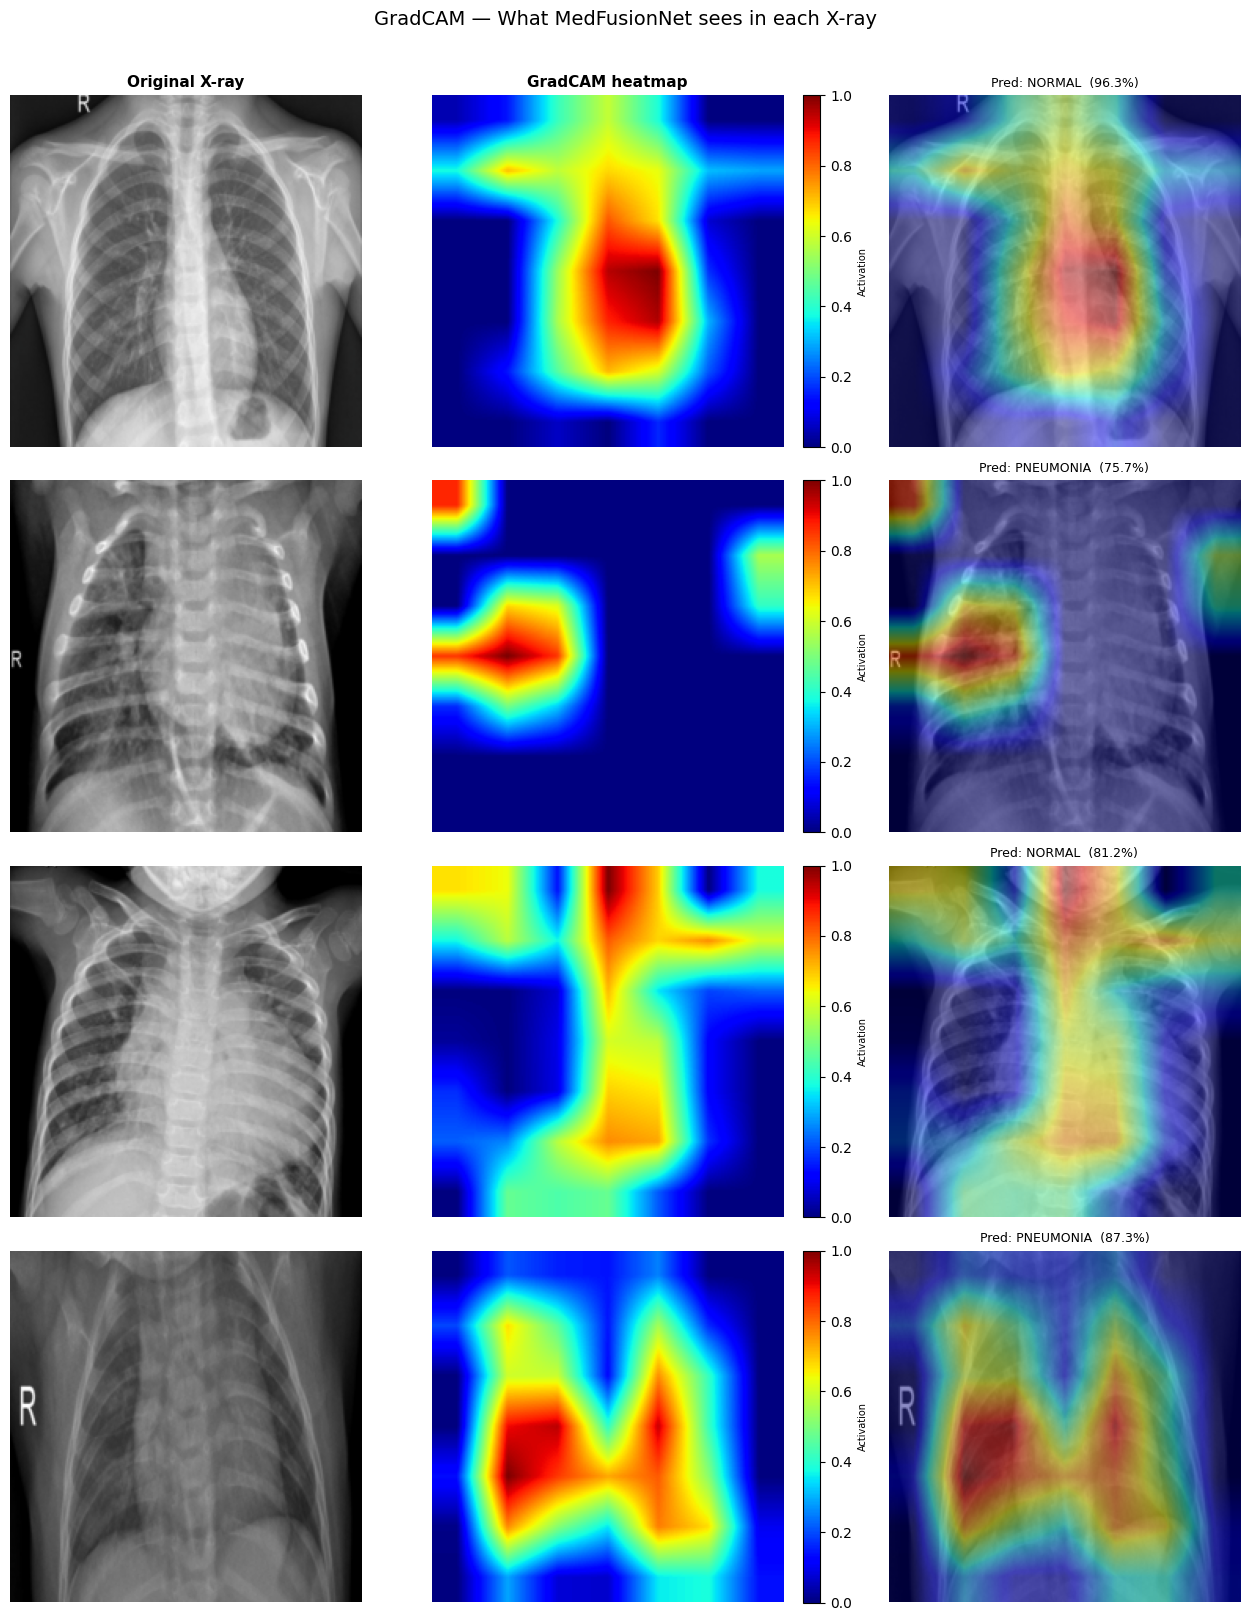

In [11]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from PIL import Image
from torchvision import transforms

# ── GradCAM implementation ─────────────────────────────────────────────────────
class GradCAM:
    """
    GradCAM for MedFusionNet.
    We hook into the last DenseNet conv layer (denseblock4) because it produces
    spatial feature maps — Swin outputs a flat vector so can't be used for GradCAM.
    """
    def __init__(self, model):
        self.model    = model
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        # Target: last dense block of DenseNet-121
        target_layer = self.model.densenet.features.denseblock4

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def generate(self, img_tensor, class_idx=None):
        """
        img_tensor : (1, 3, 224, 224) on device
        class_idx  : 0=NORMAL, 1=PNEUMONIA (None = predicted class)
        Returns    : heatmap (224, 224) numpy array in [0,1]
        """
        self.model.eval()
        img_tensor = img_tensor.requires_grad_(True)

        logits = self.model(img_tensor)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        self.model.zero_grad()
        logits[0, class_idx].backward()

        # Global average pool gradients over spatial dims
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # (1, C, 1, 1)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)
        cam     = F.relu(cam)
        cam     = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()

        # Normalise to [0, 1]
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, class_idx


# ── Preprocessing ──────────────────────────────────────────────────────────────
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225]),
])

def denorm(tensor):
    """Reverse ImageNet normalisation for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img  = tensor.cpu().squeeze().detach() * std + mean
    return img.permute(1,2,0).clamp(0,1).numpy()

def overlay_cam(img_np, cam, alpha=0.45):
    """Blend GradCAM heatmap over original image."""
    heatmap = cm.jet(cam)[:, :, :3]           # (224,224,3)  jet colormap
    overlay = alpha * heatmap + (1-alpha) * img_np
    return overlay.clip(0, 1)

def predict_and_explain(img_path, gradcam, label=None):
    img_pil    = Image.open(img_path).convert("RGB")
    img_tensor = preprocess(img_pil).unsqueeze(0).to(device)
    cam, pred_idx = gradcam.generate(img_tensor)
    prob       = torch.softmax(gradcam.model(img_tensor), dim=1)[0, pred_idx].item()
    pred_name  = class_names[pred_idx]
    img_np     = denorm(img_tensor)
    overlay    = overlay_cam(img_np, cam)
    return img_np, cam, overlay, pred_name, prob, label


# ── Build GradCAM ──────────────────────────────────────────────────────────────
gradcam = GradCAM(model)
print("✅ GradCAM ready")


# ── Pick sample images: correct + incorrect predictions ───────────────────────
import pandas as pd

pred_csv = RUN_DIR / "outputs" / "test_predictions.csv"
assert pred_csv.exists(), f"Run cell 17 first to generate predictions: {pred_csv}"

df = pd.read_csv(pred_csv)
# Add image paths back
test_ds   = loaders["test"].dataset
df["img_path"] = [test_ds.samples[i][0] for i in range(len(df))]

correct_normal    = df[(df.true_class=="NORMAL")    & (df.pred_class=="NORMAL")].iloc[0]
correct_pneumonia = df[(df.true_class=="PNEUMONIA") & (df.pred_class=="PNEUMONIA")].iloc[0]
wrong_fn          = df[(df.true_class=="PNEUMONIA") & (df.pred_class=="NORMAL")]    # missed pneumonia
wrong_fp          = df[(df.true_class=="NORMAL")    & (df.pred_class=="PNEUMONIA")] # false alarm

samples = [
    (correct_normal["img_path"],    "NORMAL",    "✅ Correct — Normal"),
    (correct_pneumonia["img_path"], "PNEUMONIA", "✅ Correct — Pneumonia"),
]
if len(wrong_fn): samples.append((wrong_fn.iloc[0]["img_path"], "PNEUMONIA", "❌ Missed — Pneumonia called Normal"))
if len(wrong_fp): samples.append((wrong_fp.iloc[0]["img_path"], "NORMAL",    "❌ False alarm — Normal called Pneumonia"))

# ── Plot ───────────────────────────────────────────────────────────────────────
n = len(samples)
fig, axes = plt.subplots(n, 3, figsize=(13, 4*n))
fig.suptitle("GradCAM — What MedFusionNet sees in each X-ray", fontsize=14, y=1.01)

col_titles = ["Original X-ray", "GradCAM heatmap", "Overlay (focus regions)"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight="bold")

for row, (img_path, true_label, caption) in enumerate(samples):
    img_np, cam, overlay, pred_name, prob, _ = predict_and_explain(
        img_path, gradcam, label=true_label)

    axes[row, 0].imshow(img_np, cmap="gray")
    axes[row, 0].set_ylabel(caption, fontsize=9, labelpad=8)

    axes[row, 1].imshow(cam, cmap="jet")
    cbar = fig.colorbar(cm.ScalarMappable(cmap="jet"), ax=axes[row,1], fraction=0.046)
    cbar.set_label("Activation", fontsize=7)

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f"Pred: {pred_name}  ({prob*100:.1f}%)", fontsize=9)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()

# Save to Drive
out_dir = RUN_DIR / "outputs"
out_dir.mkdir(exist_ok=True)
save_path = out_dir / "gradcam_results.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"✅ GradCAM saved to: {save_path}")
plt.show()

## Where Files Are Saved

Everything is saved to your Google Drive:

```
MyDrive/MedFusionNet_colab/
├── runs/<RUN_NAME>/
│   ├── checkpoints/
│   │   ├── best.pth     ← best validation AUC
│   │   └── last.pth     ← most recent epoch
│   ├── logs/
│   │   └── metrics.csv  ← epoch-by-epoch AUC, F1, Recall, loss
│   └── outputs/
│       └── test_predictions.csv
└── dataset_cache/chest_xray/   ← cached so you never re-download
```

**For a new experiment:** change `RUN_NAME` in the config cell and re-run from the training cell.

> ⚠️ Rotate your Kaggle API key after use: https://www.kaggle.com/settings